# Demand forecasting — ridge on rolling features

One small experiment a day. Seed fixed for reproducibility.

Synthetic daily demand with weekly seasonality + trend. Lag/rolling features + ridge, evaluated on the last 90 days (time split, no shuffle).

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1062

rng = np.random.RandomState(SEED)
days = pd.date_range("2023-01-01", periods=730, freq="D")
trend = np.linspace(50, 90, 730)
seasonal = 12 * np.sin(2 * np.pi * np.arange(730) / 7) + 8 * np.sin(2 * np.pi * np.arange(730) / 365)
noise = rng.normal(0, 4, 730)
y = trend + seasonal + noise
df = pd.DataFrame({"date": days, "demand": y.round(1)}).set_index("date")
print("shape:", df.shape)
print(df.head(3).to_string())
print(df.tail(3).to_string())


shape: (730, 1)
            demand
date              
2023-01-01    43.1
2023-01-02    64.6
2023-01-03    65.1
            demand
date              
2024-12-28    77.5
2024-12-29    90.0
2024-12-30    96.9


## Features

In [ ]:

df["lag_7"] = df["demand"].shift(7)
df["lag_14"] = df["demand"].shift(14)
df["roll_7"] = df["demand"].shift(1).rolling(7).mean()
df["roll_30"] = df["demand"].shift(1).rolling(30).mean()
df["dow"] = df.index.dayofweek
d = df.dropna()
print("feature rows:", d.shape)
print(d.head(3).to_string())


feature rows: (700, 6)
            demand  lag_7  lag_14     roll_7    roll_30  dow
date                                                        
2023-01-31    70.0   61.9    69.2  51.785714  52.240000    1
2023-02-01    60.0   54.9    55.3  52.942857  53.136667    2
2023-02-02    47.0   42.2    40.8  53.671429  52.983333    3


## Forecast

mae: 3.97
rmse: 4.85


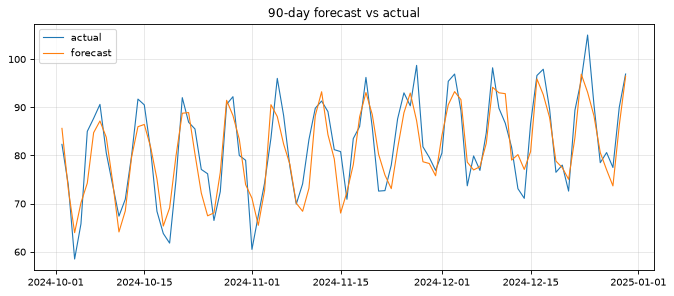

In [ ]:

feats = ["lag_7", "lag_14", "roll_7", "roll_30", "dow"]
split = len(d) - 90
Xtr, Xte = d[feats].iloc[:split], d[feats].iloc[split:]
ytr, yte = d["demand"].iloc[:split], d["demand"].iloc[split:]
model = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
model.fit(Xtr, ytr)
pred = model.predict(Xte)
print(f"mae: {mean_absolute_error(yte, pred):.2f}")
print(f"rmse: {np.sqrt(mean_squared_error(yte, pred)):.2f}")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yte.index, yte.values, label="actual", lw=1)
ax.plot(yte.index, pred, label="forecast", lw=1)
ax.legend(); ax.set_title("90-day forecast vs actual")


## Notes

- Rolling features capture the weekly seasonality well.
- Residual error is near the noise floor — the trend extrapolation is the main risk.